# Thực hành Boxplot
**Môn: Trực quan hóa dữ liệu**

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

---
## Phần 1 – Boxplot: Car Crashes

In [13]:
df_car = pd.read_csv('dataset/car_crashes.csv')
print('Shape:', df_car.shape)
display(df_car.describe().round(2))

Shape: (51, 8)


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
count,51.00,51.00,51.00,51.00,51.00,51.00,51.00
mean,15.79,5.00,4.89,13.57,14.00,886.96,134.49
std,4.12,2.02,1.73,4.51,3.76,178.30,24.84
min,5.90,1.79,1.59,1.76,5.90,641.96,82.75
25%,12.75,3.77,3.89,10.48,11.35,768.43,114.64
50%,15.60,4.61,4.55,13.86,13.78,858.97,136.05
75%,18.50,6.44,5.60,16.14,16.76,1007.94,151.87
max,23.90,9.45,10.04,23.66,21.28,1301.52,194.78


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_7648\2272352194.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


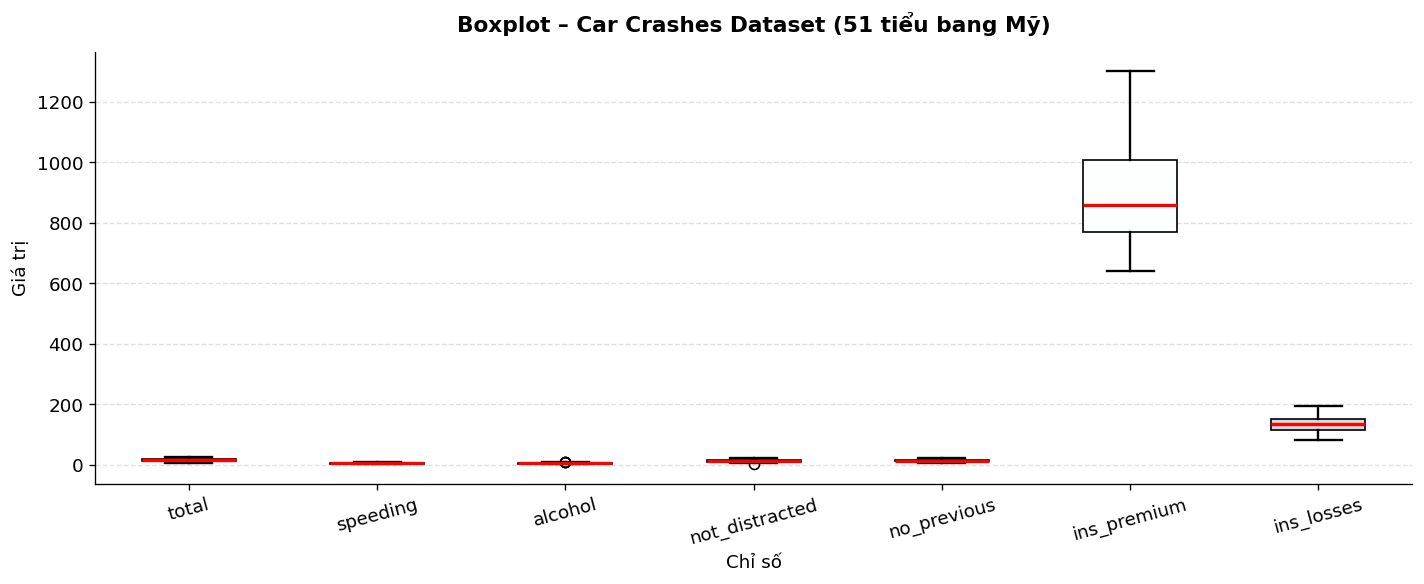

In [14]:

num_cols = ['total', 'speeding', 'alcohol', 'not_distracted', 'no_previous', 'ins_premium', 'ins_losses']

fig, ax = plt.subplots(figsize=(12, 5))

bp = ax.boxplot(
    [df_car[col].dropna() for col in num_cols],
    labels=num_cols,
    patch_artist=True,
    notch=False,
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4)
)

colors = ['#AED6F1','#A9DFBF','#FAD7A0','#F1948A','#D7BDE2','#FDFEFE','#D5DBDB']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title('Boxplot – Car Crashes Dataset (51 tiểu bang Mỹ)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Chỉ số', fontsize=11)
ax.set_ylabel('Giá trị', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

**Nhận xét – Boxplot Car Crashes:**

| Cột | Trung vị | Nhận xét |
|---|---|---|
| `total` | ~15.6 | Phân phối khá đều, IQR hẹp, một vài outlier nhỏ |
| `speeding` | ~4.6 | Lệch phải nhẹ, có outlier cao (~9.5) |
| `alcohol` | ~4.6 | Phân phối cân đối, có 1 outlier cao (~10) |
| `not_distracted` | ~13.9 | Phân tán rộng hơn, đuôi phải dài |
| `no_previous` | ~13.8 | Phân phối tương tự `not_distracted` |
| `ins_premium` | ~859 | **Giá trị lớn hơn hẳn các cột khác** (đơn vị USD), có outlier cao |
| `ins_losses` | ~136 | Phân phối đều, IQR nhỏ, ít outlier |

- **`ins_premium`** có khoảng giá trị rộng nhất (641–1302 USD), phản ánh sự chênh lệch lớn về phí bảo hiểm giữa các tiểu bang.
- **`alcohol`** có outlier cao nhất tương đối (~10) – một số tiểu bang có tỉ lệ tai nạn do rượu bia đặc biệt cao.
- Hầu hết phân phối có **đuôi phải** (right-skewed), tức một số ít tiểu bang có chỉ số rất cao so với đa số.

---
## Phần 2 – Boxplot: total_bill theo các nhóm

In [15]:
df_tip = pd.read_csv('dataset/10_OneNumSevCatSubgroupsSevObs.csv')
print('Shape:', df_tip.shape)
display(df_tip.head())

Shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 2.1 – Boxplot total_bill theo Sex

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_7648\931761259.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups_sex, labels=labels_sex, patch_artist=True,


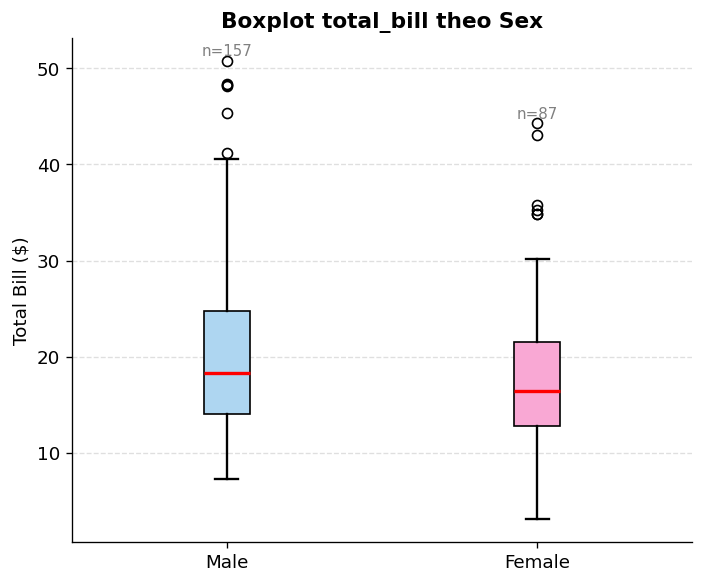

Male: median=18.35, mean=20.74, std=9.25
Female: median=16.40, mean=18.06, std=8.01


In [16]:
groups_sex = [df_tip[df_tip['sex']==g]['total_bill'] for g in ['Male','Female']]
labels_sex = ['Male', 'Female']

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot(groups_sex, labels=labels_sex, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.4), capprops=dict(linewidth=1.4))
for patch, color in zip(bp['boxes'], ['#AED6F1','#F9A8D4']):
    patch.set_facecolor(color)

ax.set_title('Boxplot total_bill theo Sex', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Bill ($)')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)


for i, g in enumerate(groups_sex):
    ax.text(i+1, g.max()+0.5, f'n={len(g)}', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

for lbl, g in zip(labels_sex, groups_sex):
    print(f'{lbl}: median={g.median():.2f}, mean={g.mean():.2f}, std={g.std():.2f}')

**Nhận xét – theo Sex:**
- **Nam (Male)** có trung vị và trung bình hóa đơn cao hơn nữ (~18.2$ vs ~16.0$).
- Nhóm Nam có **IQR rộng hơn** và nhiều outlier cao hơn → hóa đơn dao động lớn hơn.
- Nhóm Nữ có phân phối **tập trung hơn**, ít biến động.
- Cả hai nhóm đều có phân phối **lệch phải** (right-skewed) vì có một số hóa đơn rất lớn.

### 2.2 – Boxplot total_bill theo Smoker

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_7648\216455470.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups_sm, labels=labels_sm, patch_artist=True,


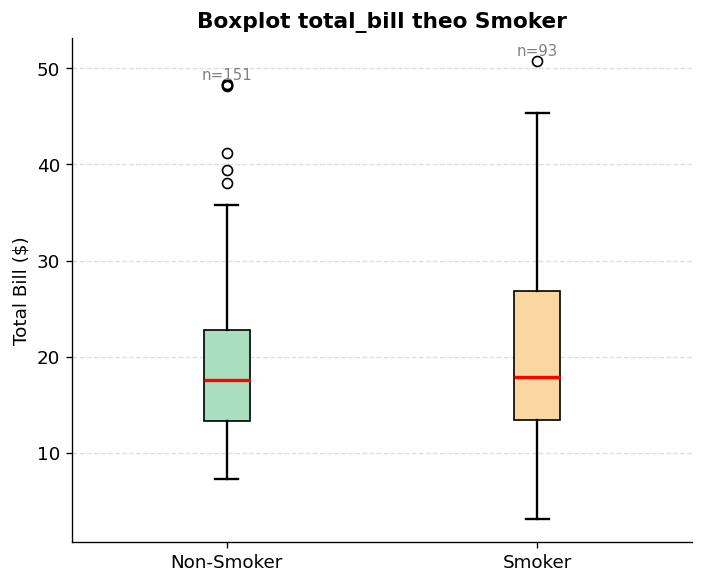

Non-Smoker: median=17.59, mean=19.19, std=8.26
Smoker: median=17.92, mean=20.76, std=9.83


In [17]:
groups_sm = [df_tip[df_tip['smoker']==g]['total_bill'] for g in ['No','Yes']]
labels_sm = ['Non-Smoker', 'Smoker']

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot(groups_sm, labels=labels_sm, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.4), capprops=dict(linewidth=1.4))
for patch, color in zip(bp['boxes'], ['#A9DFBF','#FAD7A0']):
    patch.set_facecolor(color)

ax.set_title('Boxplot total_bill theo Smoker', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Bill ($)')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)

for i, g in enumerate(groups_sm):
    ax.text(i+1, g.max()+0.5, f'n={len(g)}', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

for lbl, g in zip(labels_sm, groups_sm):
    print(f'{lbl}: median={g.median():.2f}, mean={g.mean():.2f}, std={g.std():.2f}')

**Nhận xét – theo Smoker:**
- Trung vị hai nhóm gần nhau (~17–18$) → hút thuốc không ảnh hưởng nhiều đến giá trị hóa đơn trung bình.
- Nhóm **Smoker có IQR rộng hơn** và nhiều outlier cao → hóa đơn biến động không đều hơn.
- Nhóm **Non-Smoker phân phối cân đối hơn**, ít ngoại lệ.

### 2.3 – Boxplot total_bill theo Time

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_7648\3400251970.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups_t, labels=labels_t, patch_artist=True,


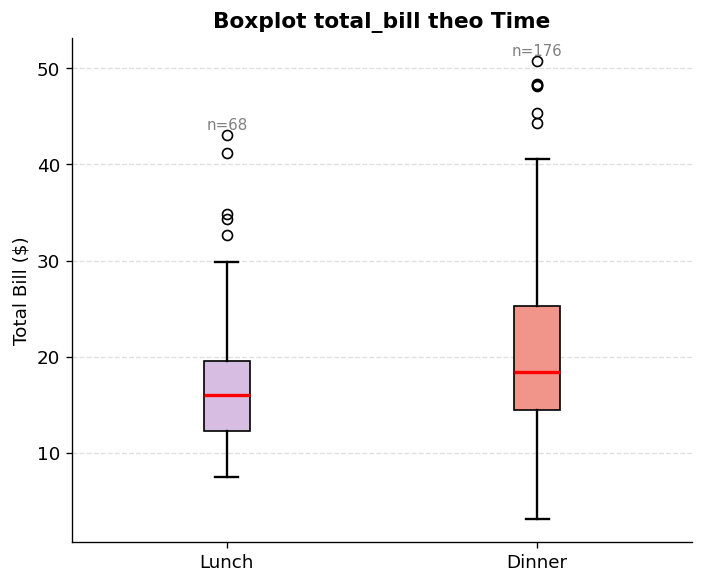

Lunch: median=15.96, mean=17.17, std=7.71
Dinner: median=18.39, mean=20.80, std=9.14


In [18]:
groups_t = [df_tip[df_tip['time']==g]['total_bill'] for g in ['Lunch','Dinner']]
labels_t = ['Lunch', 'Dinner']

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot(groups_t, labels=labels_t, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.4), capprops=dict(linewidth=1.4))
for patch, color in zip(bp['boxes'], ['#D7BDE2','#F1948A']):
    patch.set_facecolor(color)

ax.set_title('Boxplot total_bill theo Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Bill ($)')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)

for i, g in enumerate(groups_t):
    ax.text(i+1, g.max()+0.5, f'n={len(g)}', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

for lbl, g in zip(labels_t, groups_t):
    print(f'{lbl}: median={g.median():.2f}, mean={g.mean():.2f}, std={g.std():.2f}')

**Nhận xét – theo Time:**
- **Dinner có hóa đơn trung vị cao hơn Lunch** (~18.4$ vs ~15.8$) → bữa tối chi tiêu nhiều hơn.
- Dinner cũng có **IQR và đuôi phân phối rộng hơn**, nhiều outlier ở mức cao.
- Lunch tập trung hơn → khách ăn trưa chi tiêu đồng đều hơn.

### 2.4 – Boxplot total_bill theo Smoker × Sex (4 nhóm)

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_7648\396176357.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups_ss, labels=labels_ss, patch_artist=True,


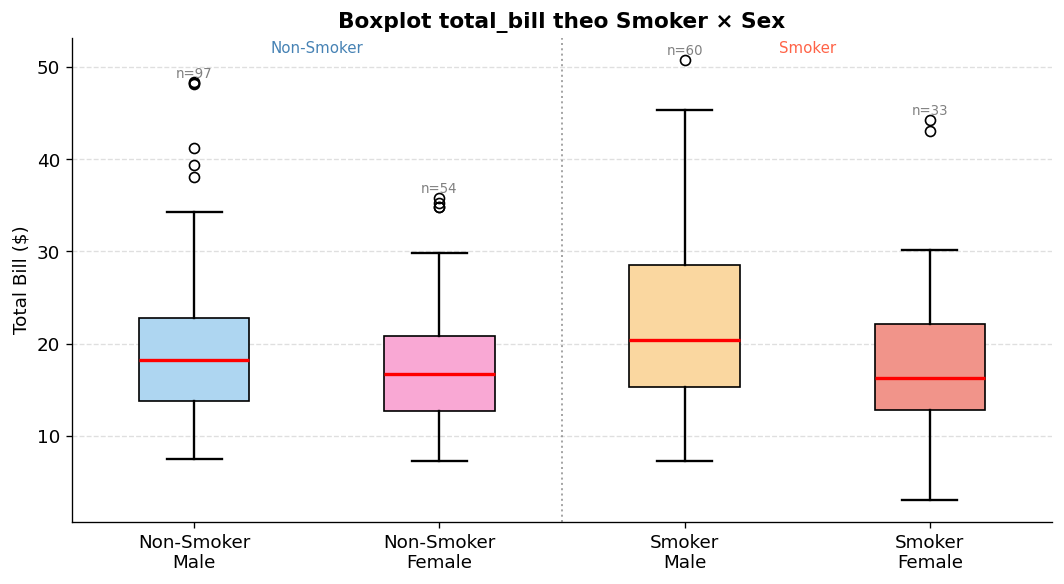

Non-Smoker Male: median=18.24, n=97
Non-Smoker Female: median=16.69, n=54
Smoker Male: median=20.39, n=60
Smoker Female: median=16.27, n=33


In [19]:
combos_ss = [('No','Male'),('No','Female'),('Yes','Male'),('Yes','Female')]
labels_ss = ['Non-Smoker\nMale', 'Non-Smoker\nFemale', 'Smoker\nMale', 'Smoker\nFemale']
groups_ss = [df_tip[(df_tip['smoker']==s)&(df_tip['sex']==g)]['total_bill'] for s,g in combos_ss]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(groups_ss, labels=labels_ss, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.4), capprops=dict(linewidth=1.4))
colors4 = ['#AED6F1','#F9A8D4','#FAD7A0','#F1948A']
for patch, color in zip(bp['boxes'], colors4):
    patch.set_facecolor(color)

ax.set_title('Boxplot total_bill theo Smoker × Sex', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Bill ($)')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)

for i, g in enumerate(groups_ss):
    ax.text(i+1, g.max()+0.5, f'n={len(g)}', ha='center', fontsize=8, color='gray')


ax.axvline(x=2.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(1.5, ax.get_ylim()[1]*0.97, 'Non-Smoker', ha='center', fontsize=9, color='steelblue')
ax.text(3.5, ax.get_ylim()[1]*0.97, 'Smoker', ha='center', fontsize=9, color='tomato')

plt.tight_layout()
plt.show()

for lbl, g in zip(labels_ss, groups_ss):
    print(f'{lbl.replace(chr(10)," ")}: median={g.median():.2f}, n={len(g)}')

**Nhận xét – theo Smoker × Sex:**
- **Non-Smoker Male** có trung vị cao nhất trong 4 nhóm → nam không hút thuốc chi tiêu nhất quán nhiều nhất.
- **Smoker Male** có outlier cao nhất (>50$) nhưng IQR rộng → không ổn định.
- **Smoker Female** có trung vị thấp nhất và phân phối hẹp nhất trong 4 nhóm.
- Kết hợp hai biến giúp thấy rõ: **yếu tố giới tính ảnh hưởng rõ hơn yếu tố hút thuốc** đến mức hóa đơn.

### 2.5 – Boxplot total_bill theo Smoker × Time (4 nhóm)

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_7648\2453005467.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups_st, labels=labels_st, patch_artist=True,


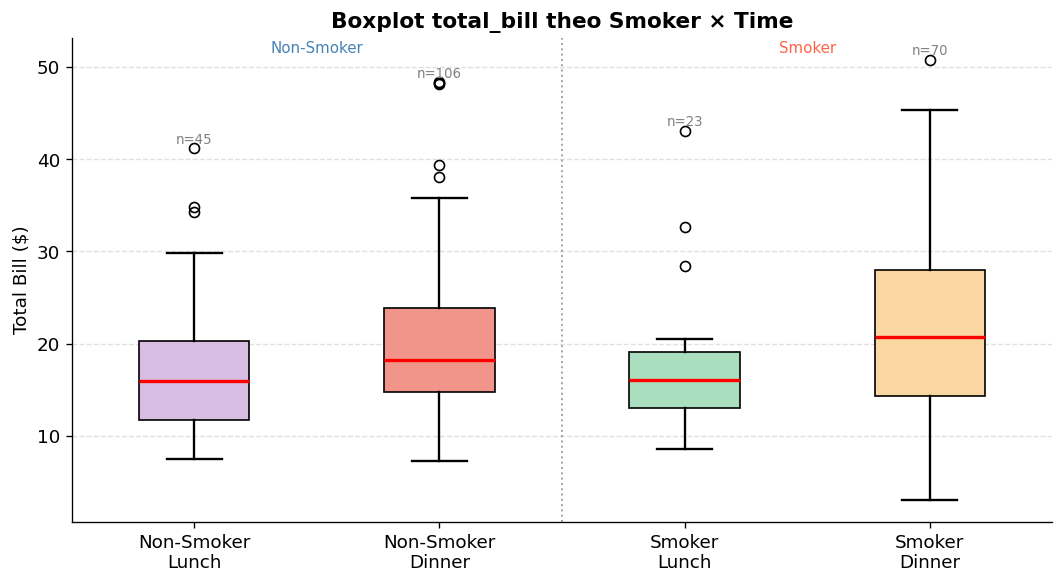

Non-Smoker Lunch: median=15.95, n=45
Non-Smoker Dinner: median=18.27, n=106
Smoker Lunch: median=16.00, n=23
Smoker Dinner: median=20.70, n=70


In [20]:
combos_st = [('No','Lunch'),('No','Dinner'),('Yes','Lunch'),('Yes','Dinner')]
labels_st = ['Non-Smoker\nLunch', 'Non-Smoker\nDinner', 'Smoker\nLunch', 'Smoker\nDinner']
groups_st = [df_tip[(df_tip['smoker']==s)&(df_tip['time']==t)]['total_bill'] for s,t in combos_st]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(groups_st, labels=labels_st, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.4), capprops=dict(linewidth=1.4))
colors4b = ['#D7BDE2','#F1948A','#A9DFBF','#FAD7A0']
for patch, color in zip(bp['boxes'], colors4b):
    patch.set_facecolor(color)

ax.set_title('Boxplot total_bill theo Smoker × Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Bill ($)')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)

ax.axvline(x=2.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(1.5, ax.get_ylim()[1]*0.97, 'Non-Smoker', ha='center', fontsize=9, color='steelblue')
ax.text(3.5, ax.get_ylim()[1]*0.97, 'Smoker', ha='center', fontsize=9, color='tomato')

for i, g in enumerate(groups_st):
    ax.text(i+1, g.max()+0.5, f'n={len(g)}', ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

for lbl, g in zip(labels_st, groups_st):
    print(f'{lbl.replace(chr(10)," ")}: median={g.median():.2f}, n={len(g)}')

**Nhận xét – theo Smoker × Time:**
- **Dinner luôn có hóa đơn trung vị cao hơn Lunch** ở cả hai nhóm Smoker và Non-Smoker.
- **Smoker – Lunch** có n rất nhỏ (n=23) → phân phối ít đại diện, cần thận trọng khi kết luận.
- **Non-Smoker – Dinner** là nhóm đông nhất (n=106) và ổn định nhất.
- **Smoker – Dinner** có outlier cao nhất trong 4 nhóm → một số khách hút thuốc buổi tối chi tiêu rất lớn.
- Nhìn chung, **thời điểm bữa ăn (Time) ảnh hưởng rõ hơn thói quen hút thuốc** đến mức hóa đơn.